<a href="https://colab.research.google.com/github/shinyb2007/2502190005_lab04/blob/main/2502190005_lab04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SMART FACTORY GUARDIAN – Autonomous Predictive Maintenance System

This Google Colab project demonstrates a simplified autonomous predictive maintenance system, acting as a digital twin for a virtual manufacturing machine. It simulates sensor data, detects anomalies, calculates a machine health score, diagnoses potential faults, and provides maintenance recommendations, all while leveraging NumPy, Pandas, SciPy, and Matplotlib for a comprehensive Industry 4.0 engineering solution.

## 1. Import Libraries

We start by importing the necessary Python libraries: `numpy` for numerical operations and data generation, `pandas` for data manipulation, `matplotlib.pyplot` for visualization, and `scipy.stats` for statistical analysis like Z-scores. We also set a random seed for reproducible results.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Set random seed for reproducibility
np.random.seed(42)

## 2. Machine Sensor Simulation: Configuration

This section defines the parameters for our virtual machine's sensor data simulation, including the total operating time, when degradation starts, and the typical operating ranges and noise levels for each sensor.

In [ ]:
# Simulation parameters
n_readings = 300 # Total number of sensor readings (time steps)
fault_start_point = 200 # Point at which degradation begins

# Normal operating parameters and noise levels
NORMAL_TEMP = 65    # °C
NORMAL_VIB = 3      # mm/s
NORMAL_RPM = 1500   # RPM
NORMAL_POWER = 5    # kW

NOISE_TEMP = 2
NOISE_VIB = 0.4
NOISE_RPM = 20
NOISE_POWER = 0.3

# Degradation rates (how much each sensor value changes per step after fault_start_point)
DEGRADATION_RATE_TEMP = 0.35 # Increase in temp per step
DEGRADATION_RATE_VIB = 0.07  # Increase in vib per step
DEGRADATION_RATE_RPM = 2.5   # Decrease in RPM per step
DEGRADATION_RATE_POWER = 0.05 # Increase in power per step

# Critical thresholds for fault detection
CRITICAL_TEMP = 80 # °C
CRITICAL_VIB = 6   # mm/s
CRITICAL_RPM_LOW = 1400 # RPM
CRITICAL_POWER = 7 # kW

## 2. Machine Sensor Simulation: Data Generation

Here, we generate synthetic sensor data over time. The machine operates normally for a period, after which a hidden fault is gradually introduced, causing sensor readings to deviate from their normal ranges. This simulates a real-world degradation process.

In [ ]:
time = np.arange(1, n_readings + 1)

# Initialize sensor data with normal behavior and random noise
temperature = NORMAL_TEMP + np.random.normal(0, NOISE_TEMP, n_readings)
vibration = NORMAL_VIB + np.random.normal(0, NOISE_VIB, n_readings)
rpm = NORMAL_RPM + np.random.normal(0, NOISE_RPM, n_readings)
power = NORMAL_POWER + np.random.normal(0, NOISE_POWER, n_readings)

# Introduce a hidden machine fault/degradation
for i in range(fault_start_point, n_readings):
    degradation_factor = (i - fault_start_point)
    temperature[i] += degradation_factor * DEGRADATION_RATE_TEMP
    vibration[i] += degradation_factor * DEGRADATION_RATE_VIB
    rpm[i] -= degradation_factor * DEGRADATION_RATE_RPM
    power[i] += degradation_factor * DEGRADATION_RATE_POWER

## 3. Data Processing: Create DataFrame

The generated sensor data is organized into a Pandas DataFrame. This structured format makes it easy to perform data manipulation, calculations, and analysis.

In [ ]:
data = pd.DataFrame({
    "Time": time,
    "Temperature": temperature,
    "Vibration": vibration,
    "RPM": rpm,
    "Power": power
})

print("Initial DataFrame head:")
display(data.head())

Initial DataFrame head:


,Time,Temperature,Vibration,RPM,Power
0,1,65.993428,2.668402,1515.139772,5.110602
1,2,64.723471,2.775928,1481.556694,4.881998
2,3,66.295377,3.298917,1517.392118,5.008623
3,4,68.046060,3.244148,1527.112757,5.383536
4,5,64.531693,2.991639,1508.268698,5.057330


## 3. Data Processing: Preprocessing & Rolling Averages

While our data is synthetic, real-world data often benefits from preprocessing. Here, we'll calculate rolling averages for each sensor reading. Rolling averages can help smooth out noise and reveal underlying trends more clearly, which is useful for identifying gradual degradation. For this simulation, the degradation is clear, but this step demonstrates a common practice.

In [ ]:
window_size = 5 # Window for rolling average

data["Temperature_MA"] = data["Temperature"].rolling(window=window_size).mean()
data["Vibration_MA"] = data["Vibration"].rolling(window=window_size).mean()
data["RPM_MA"] = data["RPM"].rolling(window=window_size).mean()
data["Power_MA"] = data["Power"].rolling(window=window_size).mean()

# Fill NaN values introduced by rolling() for initial rows, e.g., with the original values
data.fillna(method='bfill', inplace=True)

print("DataFrame head with rolling averages:")
display(data.head())

DataFrame head with rolling averages:


/tmp/ipykernel_1036/4007937892.py:9: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='bfill', inplace=True)


,Time,Temperature,Vibration,RPM,Power,Temperature_MA,Vibration_MA,RPM_MA,Power_MA
0,1,65.993428,2.668402,1515.139772,5.110602,65.918006,2.995807,1509.894008,5.088418
1,2,64.723471,2.775928,1481.556694,4.881998,65.918006,2.995807,1509.894008,5.088418
2,3,66.295377,3.298917,1517.392118,5.008623,65.918006,2.995807,1509.894008,5.088418
3,4,68.046060,3.244148,1527.112757,5.383536,65.918006,2.995807,1509.894008,5.088418
4,5,64.531693,2.991639,1508.268698,5.057330,65.918006,2.995807,1509.894008,5.088418


## 4. Anomaly Detection: SciPy Z-score Analysis

We use the Z-score from SciPy's `stats` module to identify unusual sensor readings. A Z-score measures how many standard deviations an observation is from the mean. A high absolute Z-score indicates an anomaly. We'll mark readings with an absolute Z-score greater than 2 as potentially anomalous.

In [ ]:
# Calculate absolute Z-scores for each sensor using the raw data for anomaly detection
data["Temp_Z"] = np.abs(stats.zscore(data["Temperature"]))
data["Vibration_Z"] = np.abs(stats.zscore(data["Vibration"]))
data["RPM_Z"] = np.abs(stats.zscore(data["RPM"]))
data["Power_Z"] = np.abs(stats.zscore(data["Power"]))

# Define Z-score threshold for anomaly
Z_SCORE_THRESHOLD = 2

# Count how many parameters are anomalous for each time step
data["Anomaly_Count"] = (
    (data["Temp_Z"] > Z_SCORE_THRESHOLD).astype(int) +
    (data["Vibration_Z"] > Z_SCORE_THRESHOLD).astype(int) +
    (data["RPM_Z"] > Z_SCORE_THRESHOLD).astype(int) +
    (data["Power_Z"] > Z_SCORE_THRESHOLD).astype(int)
)

print("DataFrame tail with Z-scores and anomaly counts:")
display(data.tail())

DataFrame tail with Z-scores and anomaly counts:


,Time,Temperature,Vibration,RPM,Power,Temperature_MA,Vibration_MA,RPM_MA,Power_MA,Temp_Z,Vibration_Z,RPM_Z,Power_Z,Anomaly_Count
295,296,96.864181,9.445993,1275.474198,9.882142,97.322537,9.579001,1286.596453,9.483912,2.548176,2.603680,2.577925,2.773677,4
296,297,100.399200,9.612050,1256.657638,9.794109,98.229577,9.665623,1281.398884,9.612775,2.893300,2.685264,2.840242,2.713051,4
297,298,99.564599,9.398495,1260.434274,10.015747,98.938243,9.619004,1275.219040,9.732007,2.811818,2.580344,2.787593,2.865685,4
298,299,100.925724,9.682283,1279.130179,9.967174,99.273547,9.626767,1272.867894,9.776255,2.944705,2.719769,2.526958,2.832235,4
299,300,100.909258,10.080920,1236.161287,10.359242,99.732592,9.643948,1261.571515,10.003683,2.943097,2.915619,3.125977,3.102237,4


## 5. Machine Health Score

This section calculates a composite Machine Health Score (0-100%) based on the individual sensor conditions. A weighted model is used, where each sensor's reading is normalized to a health contribution, and then combined. This provides a holistic view of the machine's state.

**Weighted Health Model Logic:**

*   **Temperature Health (30% weight):** Assesses how close the temperature is to the ideal operating temperature. Higher temperatures reduce this score.
*   **Vibration Health (30% weight):** Reflects the smoothness of operation. Increased vibration reduces the score.
*   **RPM Health (20% weight):** Measures deviation from the nominal RPM. Both too low or too high RPMs can be detrimental.
*   **Power Health (20% weight):** Indicates efficient power usage. Abnormally high power consumption reduces the score.

Each individual sensor health is scaled from 0 (critical) to 100 (optimal). The overall `Machine_Health_Score` is then the weighted sum of these individual scores.

In [ ]:
def calculate_sensor_health(value, normal_val, critical_low=None, critical_high=None):
    """Calculates a 0-100 health score for a single sensor."""
    score = 100
    if critical_low is not None and value < normal_val:
        # Linear degradation from normal to critical_low
        score = 100 * (value - critical_low) / (normal_val - critical_low)
    elif critical_high is not None and value > normal_val:
        # Linear degradation from normal to critical_high
        score = 100 * (critical_high - value) / (critical_high - normal_val)

    return np.clip(score, 0, 100)

# Define health score parameters (ideal and critical points for 0-100 scaling)
TEMP_IDEAL = NORMAL_TEMP
TEMP_CRITICAL_HIGH = CRITICAL_TEMP # Score 0 at 80°C

VIB_IDEAL = NORMAL_VIB
VIB_CRITICAL_HIGH = CRITICAL_VIB # Score 0 at 6 mm/s

RPM_IDEAL = NORMAL_RPM
RPM_CRITICAL_LOW = CRITICAL_RPM_LOW # Score 0 at 1400 RPM (degradation scenario)

POWER_IDEAL = NORMAL_POWER
POWER_CRITICAL_HIGH = CRITICAL_POWER # Score 0 at 7 kW

# Calculate individual sensor health scores
data["Temp_Health"] = data["Temperature"].apply(lambda x: calculate_sensor_health(x, TEMP_IDEAL, critical_high=TEMP_CRITICAL_HIGH))
data["Vibration_Health"] = data["Vibration"].apply(lambda x: calculate_sensor_health(x, VIB_IDEAL, critical_high=VIB_CRITICAL_HIGH))

# For RPM, we care about deviation from ideal, but our fault is degradation (low RPM)
data["RPM_Health"] = data["RPM"].apply(lambda x: calculate_sensor_health(x, RPM_IDEAL, critical_low=RPM_CRITICAL_LOW))

# For Power, we care about increase
data["Power_Health"] = data["Power"].apply(lambda x: calculate_sensor_health(x, POWER_IDEAL, critical_high=POWER_CRITICAL_HIGH))

# Weighted health score calculation
WEIGHT_TEMP = 0.30
WEIGHT_VIB = 0.30
WEIGHT_RPM = 0.20
WEIGHT_POWER = 0.20

data["Machine_Health_Score"] = (
    WEIGHT_TEMP * data["Temp_Health"] +
    WEIGHT_VIB * data["Vibration_Health"] +
    WEIGHT_RPM * data["RPM_Health"] +
    WEIGHT_POWER * data["Power_Health"]
)

# Classify machine status based on health score
def classify_status(score):
    if score >= 75:
        return "NORMAL"
    elif score >= 50:
        return "WARNING"
    else:
        return "CRITICAL"

data["Status"] = data["Machine_Health_Score"].apply(classify_status)

print("DataFrame tail with Health Scores and Status:")
display(data.tail())

DataFrame tail with Health Scores and Status:


,Time,Temperature,Vibration,RPM,Power,Temperature_MA,Vibration_MA,RPM_MA,Power_MA,Temp_Z,Vibration_Z,RPM_Z,Power_Z,Anomaly_Count,Temp_Health,Vibration_Health,RPM_Health,Power_Health,Machine_Health_Score,Status
295,296,96.864181,9.445993,1275.474198,9.882142,97.322537,9.579001,1286.596453,9.483912,2.548176,2.603680,2.577925,2.773677,4,0.0,0.0,0.0,0.0,0.0,CRITICAL
296,297,100.399200,9.612050,1256.657638,9.794109,98.229577,9.665623,1281.398884,9.612775,2.893300,2.685264,2.840242,2.713051,4,0.0,0.0,0.0,0.0,0.0,CRITICAL
297,298,99.564599,9.398495,1260.434274,10.015747,98.938243,9.619004,1275.219040,9.732007,2.811818,2.580344,2.787593,2.865685,4,0.0,0.0,0.0,0.0,0.0,CRITICAL
298,299,100.925724,9.682283,1279.130179,9.967174,99.273547,9.626767,1272.867894,9.776255,2.944705,2.719769,2.526958,2.832235,4,0.0,0.0,0.0,0.0,0.0,CRITICAL
299,300,100.909258,10.080920,1236.161287,10.359242,99.732592,9.643948,1261.571515,10.003683,2.943097,2.915619,3.125977,3.102237,4,0.0,0.0,0.0,0.0,0.0,CRITICAL


## 6. Automatic Fault Diagnosis

This section implements a rule-based expert system to automatically diagnose the most likely fault based on the latest sensor conditions. Instead of just reporting an anomaly, it provides a meaningful diagnosis and a confidence level.

**Diagnosis Logic:**

*   **Overheating:** High temperature, potentially combined with increased power.
*   **Bearing / Mechanical Vibration:** High vibration, possibly with increased temperature.
*   **RPM Degradation:** Significantly low RPM.
*   **Abnormal Power Consumption:** High power consumption.
*   **Critical Machine Degradation:** Multiple parameters severely deteriorated.

This logic allows the system to move beyond simple anomaly detection to intelligent fault identification.

In [ ]:
def diagnose_fault(latest_data):
    faults = []
    confidence = 0

    temp = latest_data["Temperature"]
    vib = latest_data["Vibration"]
    rpm = latest_data["RPM"]
    power = latest_data["Power"]
    anomaly_count = latest_data["Anomaly_Count"]
    health_score = latest_data["Machine_Health_Score"]

    # Check for individual critical conditions
    is_temp_critical = temp >= CRITICAL_TEMP - (0.1 * (CRITICAL_TEMP - NORMAL_TEMP)) # A bit below critical for warning
    is_vib_critical = vib >= CRITICAL_VIB - (0.1 * (CRITICAL_VIB - NORMAL_VIB))
    is_rpm_critical = rpm <= CRITICAL_RPM_LOW + (0.1 * (NORMAL_RPM - CRITICAL_RPM_LOW))
    is_power_critical = power >= CRITICAL_POWER - (0.1 * (CRITICAL_POWER - NORMAL_POWER))

    # Trend analysis (simple: check if latest value is significantly higher/lower than recent average)
    # Using rolling average for trend detection
    recent_avg_temp = data['Temperature_MA'].iloc[-10:-1].mean() if len(data) > 10 else NORMAL_TEMP
    recent_avg_vib = data['Vibration_MA'].iloc[-10:-1].mean() if len(data) > 10 else NORMAL_VIB
    recent_avg_rpm = data['RPM_MA'].iloc[-10:-1].mean() if len(data) > 10 else NORMAL_RPM
    recent_avg_power = data['Power_MA'].iloc[-10:-1].mean() if len(data) > 10 else NORMAL_POWER

    is_temp_increasing = temp > (recent_avg_temp + NOISE_TEMP)
    is_vib_increasing = vib > (recent_avg_vib + NOISE_VIB)
    is_rpm_decreasing = rpm < (recent_avg_rpm - NOISE_RPM)
    is_power_increasing = power > (recent_avg_power + NOISE_POWER)

    # Rule-based diagnosis
    if health_score < 50 or anomaly_count >= 3: # Overall critical state or many anomalies
        faults.append("Critical Machine Degradation")
        confidence = 95
        if is_temp_critical:
            faults.append("Severe Overheating")
        if is_vib_critical:
            faults.append("Severe Bearing/Mechanical Failure")
        if is_rpm_critical:
            faults.append("Severe RPM Degradation")
        if is_power_critical:
            faults.append("Severe Abnormal Power Consumption")

    elif health_score < 75 or anomaly_count >= 1:
        if is_vib_critical and is_temp_critical:
            faults.append("Bearing Failure / Overheating")
            confidence = 90
        elif is_vib_increasing and is_rpm_decreasing:
            faults.append("Mechanical Imbalance / Drive Train Issue")
            confidence = 85
        elif is_temp_increasing and is_power_increasing:
            faults.append("Overheating / Electrical Fault")
            confidence = 80
        elif is_rpm_decreasing and is_power_increasing:
            faults.append("Excessive Load / RPM Degradation")
            confidence = 85
        elif is_vib_critical:
            faults.append("Bearing / Mechanical Vibration")
            confidence = 70
        elif is_temp_critical:
            faults.append("Overheating")
            confidence = 65
        elif is_rpm_critical:
            faults.append("RPM Degradation")
            confidence = 60
        elif is_power_critical:
            faults.append("Abnormal Power Consumption")
            confidence = 60
        else:
            # If individual checks don't fit specific fault, but score is warning
            faults.append("General Performance Degradation")
            confidence = 50

    if not faults:
        faults.append("No major fault detected")
        confidence = 100

    return ", ".join(list(set(faults))), confidence

# Get the latest machine status
latest_snapshot = data.iloc[-1]
LIKELY_FAULT, CONFIDENCE_SCORE = diagnose_fault(latest_snapshot)

print(f"Latest Detected Fault: {LIKELY_FAULT}")
print(f"Confidence Score: {CONFIDENCE_SCORE}%")

Latest Detected Fault: Severe Overheating, Severe Abnormal Power Consumption, Severe RPM Degradation, Critical Machine Degradation, Severe Bearing/Mechanical Failure
Confidence Score: 95%


## 6. Automatic Fault Diagnosis: Maintenance Recommendation

Based on the machine's current status and identified faults, the system provides an automated maintenance recommendation. This is a crucial output for predictive maintenance, guiding proactive actions.

In [ ]:
def get_maintenance_recommendation(status, fault):
    if status == "NORMAL":
        return "Recommendation: Machine operating normally. Continue routine monitoring."
    elif status == "WARNING":
        if "Bearing" in fault or "Vibration" in fault:
            return "Recommendation: Schedule preventive maintenance. Inspect bearings and mechanical components."
        elif "Overheating" in fault:
            return "Recommendation: Schedule preventive maintenance. Check cooling system and load."
        elif "RPM Degradation" in fault or "Load" in fault:
            return "Recommendation: Schedule preventive maintenance. Assess motor, gearbox, and load conditions."
        else:
            return "Recommendation: Machine in WARNING state. Investigate sensor trends and schedule inspection."
    else: # CRITICAL
        return "Recommendation: STOP MACHINE AND INSPECT IMMEDIATELY. Address critical fault: " + fault.split(',')[0].strip() + "." # Take the primary fault

MAINTENANCE_RECOMMENDATION = get_maintenance_recommendation(latest_snapshot["Status"], LIKELY_FAULT)
print(MAINTENANCE_RECOMMENDATION)

Recommendation: STOP MACHINE AND INSPECT IMMEDIATELY. Address critical fault: Severe Overheating.


## 7. Visualization Dashboard

This section generates a professional engineering dashboard using Matplotlib. It visualizes the trends of key sensor parameters and the overall Machine Health Score over time. Critical thresholds and the fault introduction point are clearly indicated to provide a comprehensive visual diagnostic tool.

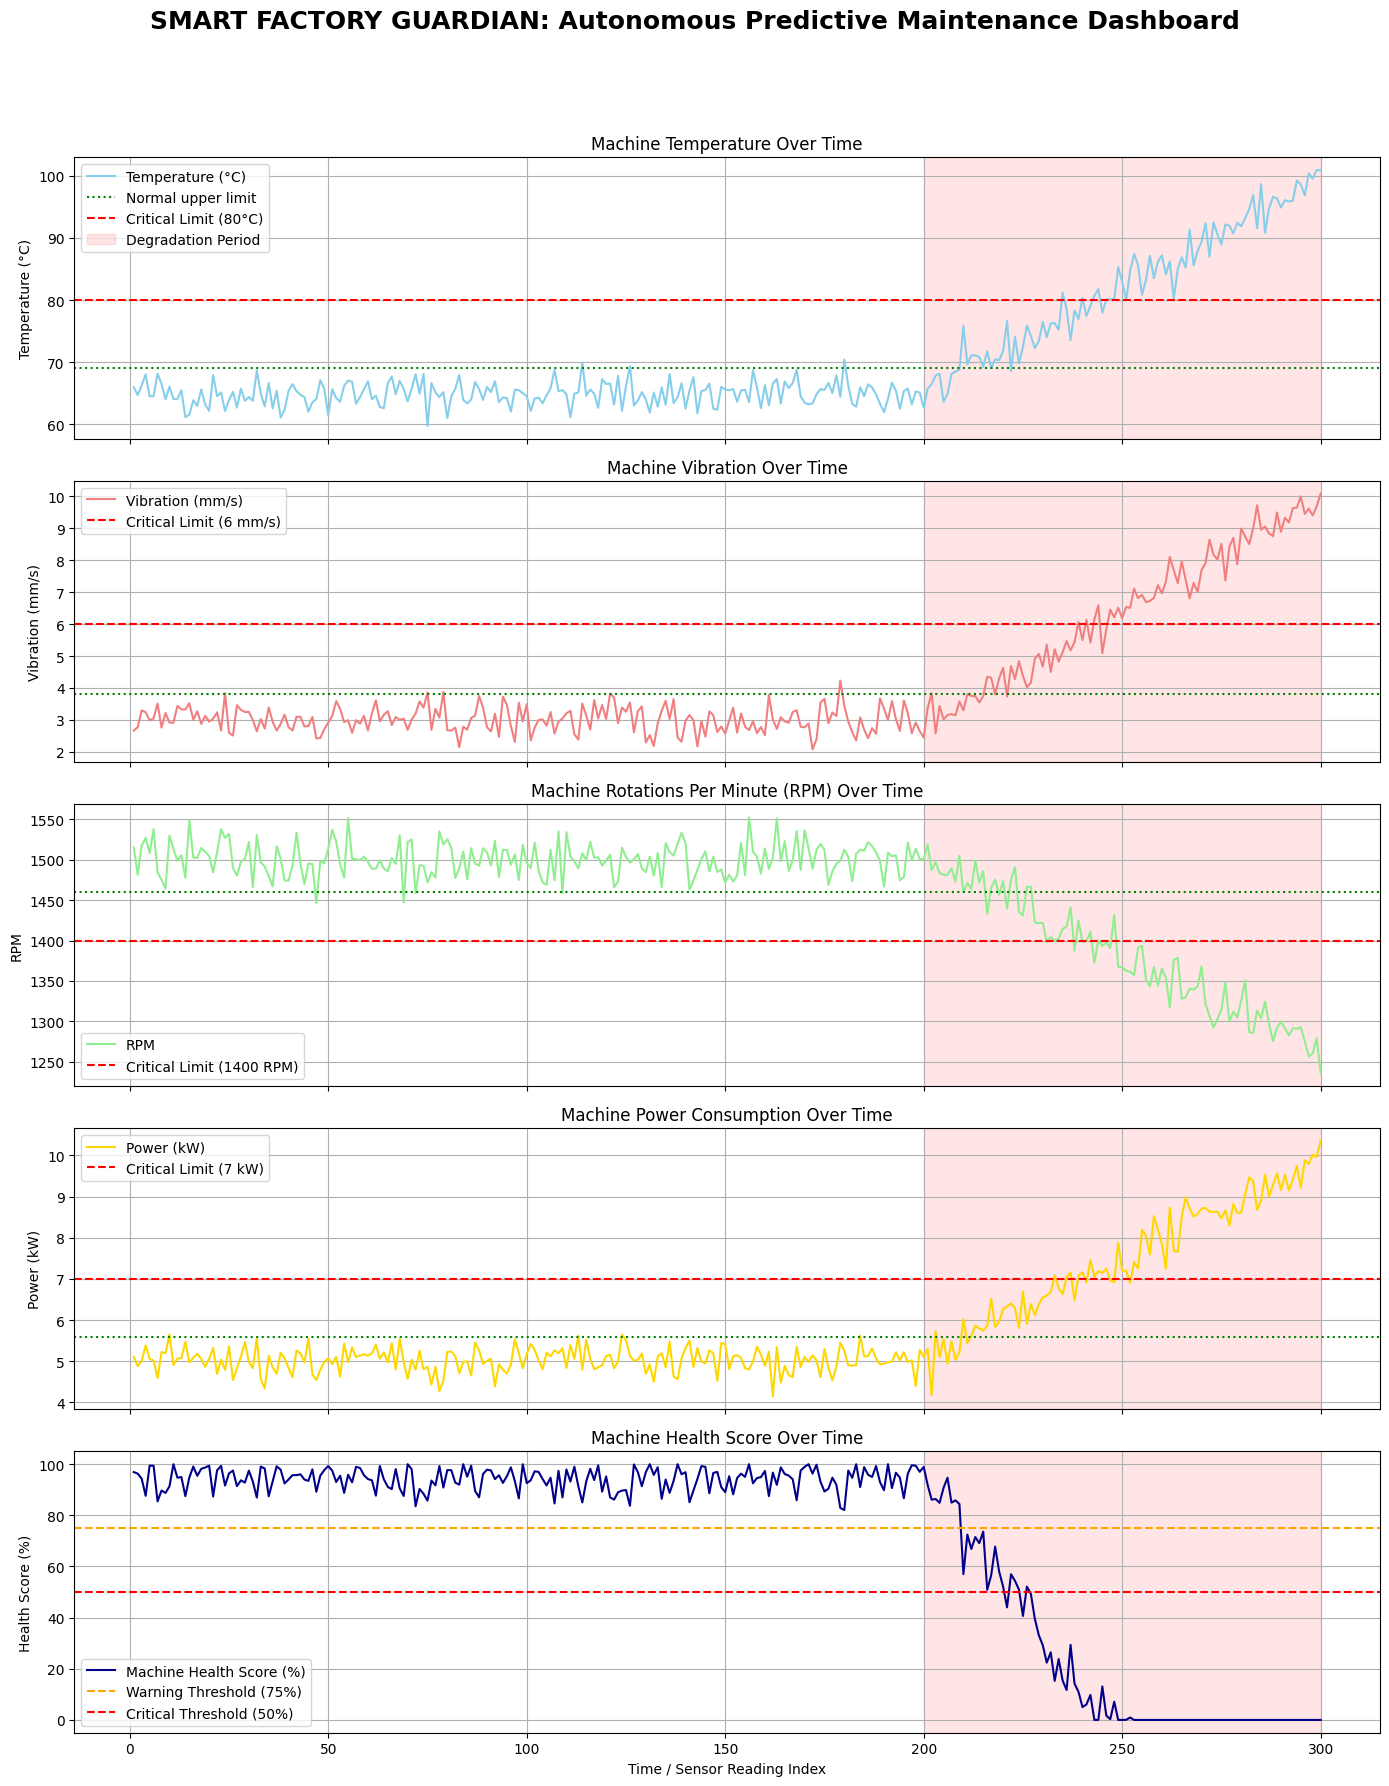

In [ ]:
fig, axes = plt.subplots(5, 1, figsize=(14, 18), sharex=True) # 5 subplots

# Define colors for status regions
NORMAL_COLOR = 'green'
WARNING_COLOR = 'orange'
CRITICAL_COLOR = 'red'

# --- Plot 1: Temperature ---
axes[0].plot(data["Time"], data["Temperature"], label="Temperature (°C)", color='skyblue')
axes[0].axhline(NORMAL_TEMP + NOISE_TEMP * 2, color=NORMAL_COLOR, linestyle=':', label='Normal upper limit')
axes[0].axhline(CRITICAL_TEMP, color=CRITICAL_COLOR, linestyle='--', label=f'Critical Limit ({CRITICAL_TEMP}°C)')
axes[0].axvspan(fault_start_point, n_readings, color='red', alpha=0.1, label='Degradation Period')
axes[0].set_ylabel("Temperature (°C)")
axes[0].set_title("Machine Temperature Over Time")
axes[0].legend()
axes[0].grid(True)

# --- Plot 2: Vibration ---
axes[1].plot(data["Time"], data["Vibration"], label="Vibration (mm/s)", color='lightcoral')
axes[1].axhline(NORMAL_VIB + NOISE_VIB * 2, color=NORMAL_COLOR, linestyle=':')
axes[1].axhline(CRITICAL_VIB, color=CRITICAL_COLOR, linestyle='--', label=f'Critical Limit ({CRITICAL_VIB} mm/s)')
axes[1].axvspan(fault_start_point, n_readings, color='red', alpha=0.1)
axes[1].set_ylabel("Vibration (mm/s)")
axes[1].set_title("Machine Vibration Over Time")
axes[1].legend()
axes[1].grid(True)

# --- Plot 3: RPM ---
axes[2].plot(data["Time"], data["RPM"], label="RPM", color='lightgreen')
axes[2].axhline(NORMAL_RPM - NOISE_RPM * 2, color=NORMAL_COLOR, linestyle=':')
axes[2].axhline(CRITICAL_RPM_LOW, color=CRITICAL_COLOR, linestyle='--', label=f'Critical Limit ({CRITICAL_RPM_LOW} RPM)')
axes[2].axvspan(fault_start_point, n_readings, color='red', alpha=0.1)
axes[2].set_ylabel("RPM")
axes[2].set_title("Machine Rotations Per Minute (RPM) Over Time")
axes[2].legend()
axes[2].grid(True)

# --- Plot 4: Power Consumption ---
axes[3].plot(data["Time"], data["Power"], label="Power (kW)", color='gold')
axes[3].axhline(NORMAL_POWER + NOISE_POWER * 2, color=NORMAL_COLOR, linestyle=':')
axes[3].axhline(CRITICAL_POWER, color=CRITICAL_COLOR, linestyle='--', label=f'Critical Limit ({CRITICAL_POWER} kW)')
axes[3].axvspan(fault_start_point, n_readings, color='red', alpha=0.1)
axes[3].set_ylabel("Power (kW)")
axes[3].set_title("Machine Power Consumption Over Time")
axes[3].legend()
axes[3].grid(True)

# --- Plot 5: Machine Health Score ---
axes[4].plot(data["Time"], data["Machine_Health_Score"], label="Machine Health Score (%)", color='darkblue')
axes[4].axhline(75, color=WARNING_COLOR, linestyle='--', label='Warning Threshold (75%)')
axes[4].axhline(50, color=CRITICAL_COLOR, linestyle='--', label='Critical Threshold (50%)')
axes[4].axvspan(fault_start_point, n_readings, color='red', alpha=0.1)
axes[4].set_xlabel("Time / Sensor Reading Index")
axes[4].set_ylabel("Health Score (%)")
axes[4].set_title("Machine Health Score Over Time")
axes[4].legend()
axes[4].grid(True)

plt.suptitle(
    "SMART FACTORY GUARDIAN: Autonomous Predictive Maintenance Dashboard",
    fontsize=18,
    fontweight="bold",
    y=1.02 # Adjust title position
)

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent overlap
plt.show()

## 8. Final Machine Report

This section consolidates all the analysis into a clear, professional machine diagnostic report, providing a quick overview of the machine's current state, detected faults, and recommended actions.

In [ ]:
print("\n" + "=" * 60)
print("       SMART FACTORY GUARDIAN: MACHINE DIAGNOSTIC REPORT")
print("=" * 60)

print(f"Machine ID: MFG-001")
print(f"Operating Cycles: {n_readings}")

print("\nLatest Sensor Readings")
print("-" * 60)
print(f"Temperature       : {latest_snapshot['Temperature']:.2f} °C")
print(f"Vibration         : {latest_snapshot['Vibration']:.2f} mm/s")
print(f"RPM               : {latest_snapshot['RPM']:.0f}")
print(f"Power             : {latest_snapshot['Power']:.2f} kW")

print("\nMachine Health")
print("-" * 60)
print(f"Health Score      : {latest_snapshot['Machine_Health_Score']:.2f} %")
print(f"Machine Status    : {latest_snapshot['Status']}")
print(f"Anomalies Found   : {int(latest_snapshot['Anomaly_Count'])}")

print("\nAutomatic Diagnosis")
print("-" * 60)
print(f"Likely Fault      : {LIKELY_FAULT}")
print(f"Confidence        : {CONFIDENCE_SCORE} %")

print("\nMaintenance Action")
print("-" * 60)
print(MAINTENANCE_RECOMMENDATION)

print("\n" + "=" * 60)


       SMART FACTORY GUARDIAN: MACHINE DIAGNOSTIC REPORT
Machine ID: MFG-001
Operating Cycles: 300

Latest Sensor Readings
------------------------------------------------------------
Temperature       : 100.91 °C
Vibration         : 10.08 mm/s
RPM               : 1236
Power             : 10.36 kW

Machine Health
------------------------------------------------------------
Health Score      : 0.00 %
Machine Status    : CRITICAL
Anomalies Found   : 4

Automatic Diagnosis
------------------------------------------------------------
Likely Fault      : Severe Overheating, Severe Abnormal Power Consumption, Severe RPM Degradation, Critical Machine Degradation, Severe Bearing/Mechanical Failure
Confidence        : 95 %

Maintenance Action
------------------------------------------------------------
Recommendation: STOP MACHINE AND INSPECT IMMEDIATELY. Address critical fault: Severe Overheating.



## 9. Viva Explanation

This section provides concise answers to common questions and a brief summary, perfect for a lab viva or presentation, explaining the core concepts and technologies used in this project.

### 1. Why did we use NumPy?
NumPy is fundamental for efficient numerical operations. We used it for generating our synthetic sensor data (arrays), adding random noise, and performing mathematical calculations quickly. Its array-oriented nature is ideal for scientific computing.

### 2. Why did we use Pandas?
Pandas was chosen for data handling and manipulation. It allowed us to structure our sensor readings into a DataFrame, making it easy to organize, clean, preprocess (e.g., calculate rolling averages), and store analytical results like Z-scores and health scores. It's excellent for tabular data.

### 3. Why did we use SciPy?
SciPy provided advanced statistical functions. Specifically, `scipy.stats.zscore` was crucial for performing Z-score based anomaly detection. This helps in statistically quantifying how unusual a sensor reading is compared to the dataset's average behavior.

### 4. Why did we use Matplotlib?
Matplotlib was used for creating all the professional visualizations, including individual sensor trends, the overall machine health score, and anomaly regions. It enabled us to build a comprehensive diagnostic dashboard with clear titles, labels, and critical thresholds, making complex data understandable at a glance.

### 5. What is predictive maintenance?
Predictive maintenance is a strategy that monitors the condition of equipment during operation to predict when a functional failure might occur. By anticipating faults, maintenance can be scheduled proactively, preventing unexpected breakdowns, reducing downtime, and lowering costs, rather than performing maintenance at fixed intervals or after failure.

### 6. What is anomaly detection?
Anomaly detection is the process of identifying data points, events, or observations that deviate significantly from the norm. In this project, we used Z-scores to detect sensor readings that are statistically unusual, indicating potential problems or early signs of degradation in the machine.

### 7. What is a Digital Twin?
A Digital Twin is a virtual model designed to accurately reflect a physical object. In this project, our simulated machine and its data processing pipeline act as a simplified Digital Twin. It follows the steps:

**Physical Machine (simulated) → Virtual Sensor Simulation → Data Processing → Anomaly Detection → Health Estimation → Fault Diagnosis → Maintenance Decision.**

This digital representation allows us to monitor, analyze, and predict the behavior of the physical machine in a virtual environment, enabling proactive decision-making without interfering with actual operations.

### 8. How is the Machine Health Score calculated?
The Machine Health Score is a weighted average of individual health scores from each sensor (Temperature, Vibration, RPM, Power). Each sensor's reading is first normalized to a 0-100 health value (100 being ideal, 0 being critical). These individual scores are then combined using predefined weights (e.g., 30% Temperature, 30% Vibration, 20% RPM, 20% Power) to produce an overall health percentage.

### 9. How does the program identify faults?
The program uses a rule-based diagnostic engine. It analyzes the latest sensor readings and their trends against predefined critical thresholds and specific fault patterns (e.g., high temperature + high vibration often indicates a bearing issue). This allows it to identify specific faults like 'Overheating' or 'RPM Degradation' rather than just reporting a generic 'anomaly'. A confidence score is also assigned based on how strongly the conditions match a fault pattern.

### 10. Why is this an Industry 4.0 application?
This project embodies several key aspects of Industry 4.0:

*   **Smart Automation:** Sensor data is automatically generated, processed, and analyzed without human intervention.
*   **Predictive Maintenance:** Moving from reactive to proactive maintenance based on machine condition.
*   **Digital Twin:** Creation of a virtual model to monitor and understand the physical asset.
*   **Data-driven Decision Making:** Automated fault diagnosis and maintenance recommendations are derived directly from real-time (simulated) data.
*   **Interconnectivity:** Sensors feeding data to a central analytical system for continuous monitoring.

### 30-Second Explanation for Lab Teacher:

"My project, 'SMART FACTORY GUARDIAN,' is a functional Digital Twin for a virtual manufacturing machine, demonstrating autonomous predictive maintenance. It simulates sensor data like temperature and vibration, automatically detects hidden degradation using statistical methods, calculates a comprehensive machine health score, and then diagnoses specific faults like 'Bearing Failure' or 'Overheating'. Finally, it presents a clear diagnostic dashboard and provides automated maintenance recommendations, showcasing a complete Industry 4.0 solution using NumPy, Pandas, SciPy, and Matplotlib."

This notebook sets up a simulation of a smart factory's autonomous predictive maintenance system. It generates sensor data, identifies potential machine faults, calculates a health score, and provides recommendations based on the machine's status.

### **1. Automatic Sensor Data Generation**

This section simulates real-world sensor data for `temperature`, `vibration`, `rpm`, and `power`. It starts with normal operating conditions and then, after a certain point (`fault_start`), introduces a gradual degradation to simulate a machine fault. This allows for testing the predictive capabilities of the system.

*   `np.random.seed(42)`: Ensures reproducibility of the random data.
*   `n = 100`: Defines the number of data points (time steps).
*   `fault_start = 70`: The time step where the fault begins to manifest.

### **2. Create DataFrame**

The simulated sensor data is then organized into a Pandas DataFrame, which is a tabular data structure commonly used for data manipulation and analysis in Python. Each row represents a time step, and each column corresponds to a sensor reading.

### **3. Statistical Analysis (Z-score)**

This part calculates the **Z-score** for each sensor reading. The Z-score measures how many standard deviations an element is from the mean. It's a common method to detect anomalies:

*   `data["Temp_Z"] = np.abs(stats.zscore(data["Temperature"]))`: Calculates the absolute Z-score for temperature.
*   `Anomaly_Count`: Counts how many sensor parameters have a Z-score greater than 2, indicating potentially abnormal readings.

### **4. Machine Health Score Calculation**

This section computes a **Machine Health Score** based on the sensor readings. It normalizes each sensor's condition into a score between 0 and 100, where 100 is optimal health.

*   `temp_score`, `vibration_score`, `rpm_score`, `power_score`: Individual scores for each parameter, using `np.clip` to keep values within 0-100 and penalizing deviations from normal operating ranges.
*   `data["Health_Score"]`: A weighted average of these individual scores, giving more importance to temperature and vibration (0.30 each) as per the defined weights.

### **5. Machine Status Classification**

Based on the `Health_Score`, the machine's status is classified into one of three categories:

*   **NORMAL**: Health score >= 75
*   **WARNING**: Health score >= 50 and < 75
*   **CRITICAL**: Health score < 50

The `machine_status` function applies these rules to determine the `Status` for each time step.

### **6. Automatic Fault Identification**

This section automatically identifies specific potential faults by checking the latest sensor readings against predefined critical thresholds:

*   **Overheating**: If temperature > 80°C
*   **Bearing / Mechanical Vibration**: If vibration > 6 mm/s
*   **RPM Degradation**: If RPM < 1400
*   **Abnormal Power Consumption**: If Power > 7 kW

The `faults` list collects all detected issues, which are then combined into a `fault_message`.

### **7. Final Machine Report**

This section generates a comprehensive text-based report summarizing the machine's current state. It displays:

*   Latest sensor readings.
*   Overall machine health score and status.
*   Number of abnormal parameters (anomaly count).
*   Detected specific fault conditions.
*   A recommended action based on the machine's status (e.g., 'Schedule preventive maintenance', 'STOP MACHINE AND INSPECT IMMEDIATELY').

### **8. Visualization**

Finally, this section visualizes the trends of the key sensor parameters and the overall machine health score over time using `matplotlib`. This provides a clear graphical representation of the machine's behavior and the progression of any detected faults.

*   Four subplots display Temperature, Vibration, RPM, and Health Score.
*   Horizontal dashed lines (`axhline`) indicate critical or warning limits for each parameter, making it easy to see when thresholds are crossed.
*   The `plt.suptitle` adds an overall title to the set of plots.